In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

data=pd.read_csv('day-wise-state-wise-air-quality-index-aqi-of-major-cities-and-towns-in-india.csv')

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425971 entries, 0 to 425970
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   date                           425971 non-null  object 
 1   state                          425971 non-null  object 
 2   area                           425971 non-null  object 
 3   number_of_monitoring_stations  425830 non-null  float64
 4   prominent_pollutants           425970 non-null  object 
 5   aqi_value                      425971 non-null  float64
 6   air_quality_status             425971 non-null  object 
 7   unit                           425971 non-null  object 
 8   note                           0 non-null       float64
dtypes: float64(3), object(6)
memory usage: 29.2+ MB


In [40]:
data.describe()

,number_of_monitoring_stations,aqi_value,note
count,425830.000000,425971.000000,0.0
mean,1.825616,118.853737,NaN
std,3.136948,79.658891,NaN
min,1.000000,3.000000,NaN
25%,1.000000,61.000000,NaN
50%,1.000000,96.000000,NaN
75%,1.000000,153.000000,NaN
max,40.000000,500.000000,NaN


In [41]:
data.head()

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,19-06-2025,Uttar Pradesh,Agra,5.0,"O3,PM2.5,PM10",49.0,Good,number_of_monitoring_stations in Absolute Numb...,NaN
1,19-06-2025,Karnataka,Bagalkot,1.0,PM10,46.0,Good,number_of_monitoring_stations in Absolute Numb...,NaN
2,19-06-2025,Maharashtra,Akola,1.0,PM10,26.0,Good,number_of_monitoring_stations in Absolute Numb...,NaN
3,19-06-2025,Rajasthan,Alwar,1.0,CO,76.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
4,19-06-2025,Andhra Pradesh,Amaravati,1.0,PM10,66.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN


In [42]:
#checking for null values and duplicate values

print(data.isnull().sum())
print('Duplicate rows : ',data.duplicated().sum())

date                                  0
state                                 0
area                                  0
number_of_monitoring_stations       141
prominent_pollutants                  1
aqi_value                             0
air_quality_status                    0
unit                                  0
note                             425971
dtype: int64
Duplicate rows :  0


In [43]:
#dropping unnecessary columns
data.drop(['number_of_monitoring_stations','unit','note'],axis=1,inplace=True)

In [44]:
#dropping row with null value in prominent_pollutants column
data.dropna(subset='prominent_pollutants',inplace=True)

#### Data quality issues 
- missing values in columns **(number_of_monitoring_stations,prominent_pollutants)**
- dropping unnecessary columns **(unit,note,number_of_monitoring_stations)**
- dropping rows with null values in **prominent_pollutants** column
- no duplicate records

---
## PRIMARY ANALYSIS (BASED ON AVAILABLE DATA)

 1. List the top 5 and bottom 5 areas with highest average AQI. (Consider areas 
which contains data from last 6 months: December 2024 to May 2025)

---

In [45]:
data['date']=pd.to_datetime(data['date'],format='%d-%m-%Y',errors='coerce').copy()
df=data[(data['date']>='2024-12-01') & (data['date']<='2025-05-31')]
#Top 5 areas with highest AQI
highest_avg_aqi=df.groupby('area')['aqi_value'].mean().reset_index(name='avg_aqi').sort_values('avg_aqi',ascending=False).head(5)
print('Top 5 areas with highest AQI \n',highest_avg_aqi,'\n')

#Top 5 areas with lowest AQI 
lowest_avg_aqi=df.groupby('area')['aqi_value'].mean().reset_index(name='avg_aqi').sort_values('avg_aqi',ascending=False).tail(5)
print('Bottom 5 areas with lowest AQI\n',lowest_avg_aqi)

Top 5 areas with highest AQI 
             area     avg_aqi
60      Byrnihat  265.309353
81         Delhi  227.038674
24   Bahadurgarh  226.437500
106      Hajipur  217.114458
103     Gurugram  197.022599 

Bottom 5 areas with lowest AQI
                area    avg_aqi
61   Chamarajanagar  44.929032
257       Thanjavur  44.326087
200   Palkalaiperur  40.691176
163        Madikeri  40.239766
263     Tirunelveli  33.167742


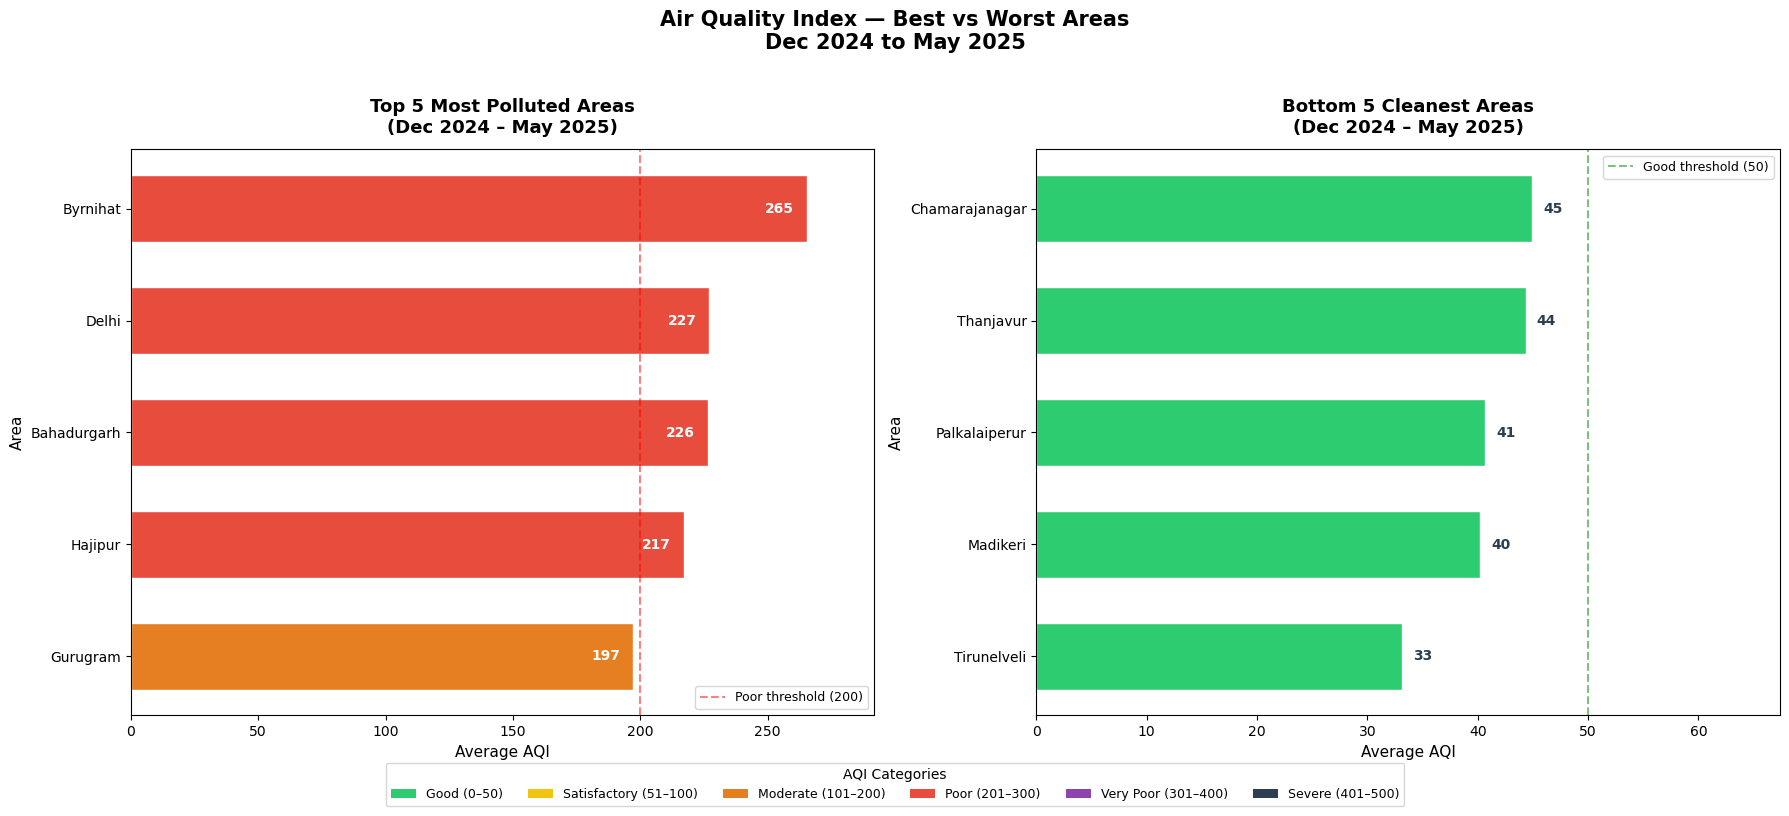

In [46]:

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))

# --- Color coding based on AQI severity ---
def get_colors(aqi_values):
    colors = []
    for val in aqi_values:
        if val <= 50:
            colors.append('#2ecc71')    # Good - Green
        elif val <= 100:
            colors.append('#f1c40f')    # Satisfactory - Yellow
        elif val <= 200:
            colors.append('#e67e22')    # Moderate - Orange
        elif val <= 300:
            colors.append('#e74c3c')    # Poor - Red
        elif val <= 400:
            colors.append('#8e44ad')    # Very Poor - Purple
        else:
            colors.append('#2c3e50')    # Severe - Dark
    return colors

# --- Chart 1: Top 5 Highest AQI ---
top_colors = get_colors(highest_avg_aqi['avg_aqi'])

bars1 = axes[0].barh(
    highest_avg_aqi['area'],
    highest_avg_aqi['avg_aqi'],
    color=top_colors,
    edgecolor='white',
    height=0.6
)

# Add value labels on bars
for bar, val in zip(bars1, highest_avg_aqi['avg_aqi']):
    axes[0].text(
        bar.get_width() - 5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.0f}',
        va='center', ha='right',
        fontsize=10, fontweight='bold', color='white'
    )

axes[0].set_title('Top 5 Most Polluted Areas\n(Dec 2024 – May 2025)',
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Average AQI', fontsize=11)
axes[0].set_ylabel('Area', fontsize=11)
axes[0].invert_yaxis()   # worst at top
axes[0].axvline(x=200, color='red', linestyle='--',
                alpha=0.5, label='Poor threshold (200)')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, highest_avg_aqi['avg_aqi'].max() * 1.1)

# --- Chart 2: Bottom 5 Lowest AQI ---
bot_colors = get_colors(lowest_avg_aqi['avg_aqi'])

bars2 = axes[1].barh(
    lowest_avg_aqi['area'],
    lowest_avg_aqi['avg_aqi'],
    color=bot_colors,
    edgecolor='white',
    height=0.6
)

# Add value labels on bars
for bar, val in zip(bars2, lowest_avg_aqi['avg_aqi']):
    axes[1].text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.0f}',
        va='center', ha='left',
        fontsize=10, fontweight='bold', color='#2c3e50'
    )

axes[1].set_title('Bottom 5 Cleanest Areas\n(Dec 2024 – May 2025)',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Average AQI', fontsize=11)
axes[1].set_ylabel('Area', fontsize=11)
axes[1].invert_yaxis()   # best at top
axes[1].axvline(x=50, color='green', linestyle='--',
                alpha=0.5, label='Good threshold (50)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, lowest_avg_aqi['avg_aqi'].max() * 1.5)

# --- AQI Legend ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Good (0–50)'),
    Patch(facecolor='#f1c40f', label='Satisfactory (51–100)'),
    Patch(facecolor='#e67e22', label='Moderate (101–200)'),
    Patch(facecolor='#e74c3c', label='Poor (201–300)'),
    Patch(facecolor='#8e44ad', label='Very Poor (301–400)'),
    Patch(facecolor='#2c3e50', label='Severe (401–500)'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=6,
    fontsize=9,
    title='AQI Categories',
    title_fontsize=10,
    bbox_to_anchor=(0.5, -0.05),
    frameon=True
)

# --- Overall title ---
fig.suptitle('Air Quality Index — Best vs Worst Areas\nDec 2024 to May 2025',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

In [47]:
most_polluted_cities=['Byrnihat','Delhi','Bahadurgarh','Hajipur','Gurugram']
polluted_cities_data=df[df['area'].isin(most_polluted_cities)].copy()
polluted_cities_data['prominent_pollutants']=polluted_cities_data['prominent_pollutants'].str.split(',')
polluted_cities_data=polluted_cities_data.explode('prominent_pollutants')
#finding prominent_pollutants in the top polluted cities in India in last 6 months
pollutants=polluted_cities_data.groupby(['area','prominent_pollutants']).size().reset_index(name='pollutants_count')
res=pd.DataFrame(pollutants)
result_1=[]
for cities in res['area'].unique():
    subset=res[res['area'] == cities].sort_values(by='pollutants_count',ascending=False)
    top_2=subset.head(2)
    result_1.append(top_2)
print(pd.concat(result_1))


           area prominent_pollutants  pollutants_count
1   Bahadurgarh                PM2.5                15
0   Bahadurgarh                 PM10                 1
3      Byrnihat                PM2.5               136
2      Byrnihat                 PM10                 3
8         Delhi                PM2.5               115
7         Delhi                 PM10                86
13     Gurugram                PM2.5               138
12     Gurugram                 PM10                96
16      Hajipur                PM2.5               141
14      Hajipur                   O3                24


### Key Insights 
- The top 5 most polluted cities in India in the last 6 months are  Bahadurgarh, Byrnihat, Delhi, Gurugram, Hajipur with average AQI greater than 200.
- Every city in the dataset shows **PM2.5** as the most frequently recorded pollutant- not PM10, not NO2, not O3. This is consistent and significant.

  **Business Implication**:H13 HEPA filtration(which captures PM2.5 at 99.95% efficiency) is non-negotiable.

- Hajipur, Gurugram, Byrnihat experiences PM2.5 as their dominant pollutant for roughly 4-5 months of the year- not a seasonal spike, a persistent structural problem.
  
   **Business Implication**:These are Tier 1 priority markets for AirPure's Launch. Hajipur and Gurugram should be the first cities targeted for distribution and marketing.

- Delhi is the only city with both PM2.5(115 days) and PM10(86 days) occuring at high frequency simultaneously. Every other city has a dominant primary pollutant with a distant second.

   **Business Implication** :Delhi and Gurugram need a purifier optimised for both PM2.5 and PM10 - a multi-stage HEPA system. Byrnihat needs a PM2.5 specialized product. This supports the case for city-specific product configurations rather than a one-size-fits-all products.
